# 인천e음 캐시백 확대와 카드소비 대체효과 — 인천 집중 EDA

**공모전** AI금융빅데이터플랫폼 제1회 공모전 · **데이터** `ABP_CONTEST_DATA.csv` — BC카드 2026년 1~6월, 시군구 × 업종 × 소비 주체 월별 집계

**질문** 2026년 5~7월 인천e음 캐시백 확대(10% → 20%, 월 한도 30 → 50만원)가 인천의 **BC카드 소비를 얼마나 대체**했는가?

**전제 — 해석의 방향을 정한다**
- 인천e음 운영사(코나아이)는 2023년 8월 BC카드 결제망에서 KB국민카드 결제망으로 이전했다 → **이 데이터에 인천e음 결제는 들어 있지 않다.**
- 따라서 대체효과는 인천의 BC카드 소비가 전국 추세 대비 **덜 늘거나 줄어드는 것**으로 관측된다. 5~6월에 인천만 빠지면 그것이 신호다.

| 컬럼 | 정의 |
|---|---|
| `STRD_YYMM` | 기준년월 (202601~202606) |
| `SIDO_NM` / `CCG_NM` | 광역시도 / 시군구 |
| `GENDER_CD` | 1=남성, 2=여성, 3=외국인, x=법인 — **성별이 아니라 소비 주체 구분** |
| `AGE_CD` | 1=20대 이하 … 6=60대 이상, x=법인 |
| `TP_BUZ_NO` / `TP_BUZ_NM` | 업종 코드 / 명칭 (외식 8종 + 식료품 유통 3종) |
| `amt` / `cnt` | 이용금액 합계(원) / 이용건수 합계(건) |

**흐름** 0 환경 → 1 데이터 실사 → 2 정책 타임라인 → 3 인천 프로파일 → 4 시계열 → 5 사전 추세·반사실 갭 → 6 전국 속 인천의 위치 → 7 업종별(플라시보) → 8 군구별 → 9 소비 주체·연령 → 10 인접 지역 → 11 요약·본분석 설계

## 0. 환경 설정

In [1]:
import warnings; warnings.filterwarnings("ignore")
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager as fm
from matplotlib.patches import Patch

# ── 한글 폰트
_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if _f in _avail:
        mpl.rc("font", family=_f); break
mpl.rc("axes", unicode_minus=False)

# ── 팔레트 (카테고리 색은 고정 순서, 인접쌍 색각이상 대비 검증 통과) · 텍스트/격자 토큰
C = {"인천": "#2a78d6", "서울·경기": "#eb6834", "5대 광역시": "#1baf7a", "전국(인천 제외)": "#898781",
     "up": "#e34948", "ref": "#c3c2b7", "wash": "#f0efec",
     "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#898781", "grid": "#e1e0d9"}
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C["ref"], "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.8, "grid.linestyle": "-", "axes.axisbelow": True,
    "xtick.color": C["ink2"], "ytick.color": C["ink2"], "axes.labelcolor": C["ink2"],
    "axes.titlecolor": C["ink"], "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 6,
})
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)

CSV = "ABP_CONTEST_DATA.csv"
EOK = 1e8                                            # 억원
MONTHS = [202601, 202602, 202603, 202604, 202605, 202606]
MLAB   = ["1월", "2월", "3월", "4월", "5월", "6월"]
PRE, POST = MONTHS[:4], MONTHS[4:]                   # 캐시백 10% 기간 / 20% 기간
BIG5 = ["부산광역시", "대구광역시", "광주광역시", "대전광역시", "울산광역시"]

SEG = {"1": "남성", "2": "여성", "3": "외국인", "x": "법인"}
AGE = {"1": "20대 이하", "2": "20대", "3": "30대", "4": "40대", "5": "50대", "6": "60대 이상", "x": "법인"}
AGE_ORDER = ["20대 이하", "20대", "30대", "40대", "50대", "60대 이상"]

# ── 공통 함수
def msum(d, col="amt"):
    """월별 합계 (6개월 인덱스 보장)"""
    return d.groupby("STRD_YYMM")[col].sum().reindex(MONTHS)

def munit(d):
    """월별 객단가"""
    return msum(d, "amt") / msum(d, "cnt")

def idx(s):
    """1~4월 평균 = 100 지수"""
    return s / s.loc[PRE].mean() * 100

def prepost(d, by, col="amt"):
    """그룹별 (5~6월 월평균 / 1~4월 월평균 - 1) × 100"""
    pre  = d[d["STRD_YYMM"].isin(PRE)].groupby(by)[col].sum() / len(PRE)
    post = d[d["STRD_YYMM"].isin(POST)].groupby(by)[col].sum() / len(POST)
    return (post / pre - 1) * 100

def pp_total(d, col="amt"):
    """전체 (5~6월 월평균 / 1~4월 월평균 - 1) × 100"""
    s = msum(d, col); return (s.loc[POST].mean() / s.loc[PRE].mean() - 1) * 100

def shade(ax, y=100):
    """캐시백 20% 기간(5~6월) 음영 + 기준선 + 월 눈금"""
    ax.axvspan(3.5, 5.5, color=C["wash"], zorder=0, lw=0)
    ax.axhline(y, color=C["ref"], lw=0.8, zorder=1)
    ax.set_xticks(range(6)); ax.set_xticklabels(MLAB)

def line(ax, y, name, color=None, label_end=True):
    """지수 라인 (마커에 흰 링) + 끝점 직접 라벨"""
    color = color or C.get(name, C["muted"])
    ax.plot(range(6), list(y), marker="o", color=color, mec="white", mew=1.5, label=name, zorder=3)
    if label_end:
        ax.annotate(f"{y.iloc[-1]:.0f}", (5, y.iloc[-1]), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9, color=C["ink"])

## 1. 데이터 실사
전체 품질을 확인한 뒤, 인천의 셀 커버리지(어느 군구·업종에 행이 비는지)까지 본다.

In [2]:
df = pd.read_csv(CSV, dtype={"GENDER_CD": str, "AGE_CD": str, "TP_BUZ_NO": str})
KEYS = ["STRD_YYMM", "SIDO_NM", "CCG_NM", "GENDER_CD", "AGE_CD", "TP_BUZ_NO"]

print("shape     :", df.shape)
print("결측치    :", int(df.isna().sum().sum()), " / 키 중복 :", int(df.duplicated(KEYS).sum()))
print("amt<=0    :", int((df.amt <= 0).sum()), " / cnt<=0 :", int((df.cnt <= 0).sum()))
print("기간      :", df.STRD_YYMM.min(), "~", df.STRD_YYMM.max(), f"({df.STRD_YYMM.nunique()}개월)")
print("커버리지  :", df.SIDO_NM.nunique(), "시도 /", df.groupby(["SIDO_NM", "CCG_NM"]).ngroups, "시군구 /", df.TP_BUZ_NO.nunique(), "업종")
print("셀 하한   : amt 최소", f"{df.amt.min():,}원 / cnt 최소", df.cnt.min(), "건  → 소액·소건수 셀은 미수록(합계는 소폭 과소)")
print("금액 단위 : 만원 단위 반올림 비율", (df.amt % 10_000 == 0).mean())
print(f"\n총 결제금액 {df.amt.sum()/1e12:,.2f}조원 · 총 결제건수 {df.cnt.sum()/1e8:,.2f}억 건 · 객단가 {df.amt.sum()/df.cnt.sum():,.0f}원")

print("\n[ 코드북 실측 : 소비 주체 × 연령 행수 ]  — 외국인도 연령 코드 보유, 'x'는 법인 전용")
display(pd.crosstab(df.GENDER_CD.map(SEG), df.AGE_CD.map(AGE)).reindex(["남성", "여성", "외국인", "법인"]))
print("[ 업종 ]")
display(df.groupby(["TP_BUZ_NO", "TP_BUZ_NM"]).agg(행수=("amt", "size"), 금액_억=("amt", lambda s: s.sum() / EOK))
          .sort_values("금액_억", ascending=False).round(0))

shape     : (242574, 9)
결측치    : 0  / 키 중복 : 0
amt<=0    : 0  / cnt<=0 : 0
기간      : 202601 ~ 202606 (6개월)
커버리지  : 17 시도 / 255 시군구 / 11 업종
셀 하한   : amt 최소 20,000원 / cnt 최소 11 건  → 소액·소건수 셀은 미수록(합계는 소폭 과소)
금액 단위 : 만원 단위 반올림 비율 1.0

총 결제금액 17.22조원 · 총 결제건수 9.49억 건 · 객단가 18,149원

[ 코드북 실측 : 소비 주체 × 연령 행수 ]  — 외국인도 연령 코드 보유, 'x'는 법인 전용


AGE_CD,20대,20대 이하,30대,40대,50대,60대 이상,법인
GENDER_CD,,,,,,,
남성,13241,12181,13480,13679,13929,14044,0
여성,13040,11546,13291,13442,13633,13729,0
외국인,12152,7566,12564,12641,12702,12553,0
법인,0,0,0,0,0,0,13161


[ 업종 ]


,,행수,금액_억
TP_BUZ_NO,TP_BUZ_NM,,
8001,일반한식,28406,"63,485.0"
4020,슈퍼 마켓,28456,"27,239.0"
4010,편 의 점,28967,"24,839.0"
8006,서양음식,28627,"19,161.0"
4004,대형할인점,21529,"16,548.0"
8021,스넥,27438,"5,715.0"
8005,중국음식,26805,"5,296.0"
8301,제 과 점,27224,"4,984.0"
8004,일식회집,21714,"4,878.0"


In [3]:
# 파생 변수
df["seg"]     = df.GENDER_CD.map(SEG)
df["age"]     = df.AGE_CD.map(AGE)
df["region"]  = df.SIDO_NM + " " + df.CCG_NM
df["biz"]     = df.TP_BUZ_NM.str.replace(" ", "")               # '편 의 점' → '편의점'
df["is_ind"]  = df.GENDER_CD.isin(["1", "2"])                    # 내국인 개인
df["is_ic"]   = df.SIDO_NM.eq("인천광역시")
df["n_month"] = df.groupby(KEYS[1:]).STRD_YYMM.transform("nunique")   # 셀이 수록된 월 수 (균형패널 검정용)

ind      = df[df.is_ind]                                          # 내국인 개인 — 성별·연령·대체효과 분석의 기준
icn, nat = ind[ind.is_ic], ind[~ind.is_ic]                        # 인천 / 전국(인천 제외)
ic_all   = df[df.is_ic]
print(f"전체 {len(df):,}행 · 내국인 개인 {len(ind):,}행 · 인천 {len(ic_all):,}행 (인천 내국인 개인 {len(icn):,}행)")

# 월별 행수 안정성 — 5~6월 변화가 '수록 범위' 변화가 아닌지
display(pd.crosstab(df.STRD_YYMM, df.is_ic).rename(columns={True: "인천 행수", False: "전국(인천 제외) 행수"}))

전체 242,574행 · 내국인 개인 159,235행 · 인천 9,623행 (인천 내국인 개인 6,317행)


is_ic,전국(인천 제외) 행수,인천 행수
STRD_YYMM,,
202601,38668,1599
202602,38562,1598
202603,38818,1615
202604,38893,1614
202605,39093,1603
202606,38917,1594


In [4]:
# 인천 커버리지 : 군구 × 업종 행수 (최대 114 = 6개월 × 19개 주체·연령 조합)
FULL = 6 * (3 * 6 + 1)
cov = pd.crosstab(ic_all.CCG_NM, ic_all.biz)
display(cov)

g = ic_all.groupby("CCG_NM").agg(행수=("amt", "size"), 금액_억=("amt", lambda s: s.sum() / EOK), 건수_만=("cnt", lambda s: s.sum() / 1e4))
g["커버리지%"] = g["행수"] / (FULL * 11) * 100
display(g.sort_values("금액_억", ascending=False).round(1))

biz,갈비전문점,대형할인점,서양음식,슈퍼마켓,스넥,일반한식,일식회집,제과점,중국음식,편의점,한정식
CCG_NM,,,,,,,,,,,
강화군,31,0,109,114,105,108,83,102,103,114,0
계양구,0,108,114,114,109,114,104,111,108,114,0
남동구,20,112,114,114,113,114,108,112,112,114,11
동구,0,104,108,110,103,109,51,106,100,114,0
미추홀구,0,114,114,114,114,114,108,114,114,114,0
부평구,9,114,114,114,114,114,108,114,114,114,0
서구,0,113,114,114,114,114,108,114,113,114,0
연수구,0,114,114,114,114,114,113,114,114,114,0
옹진군,2,30,103,102,76,102,47,63,66,113,0


,행수,금액_억,건수_만,커버리지%
CCG_NM,,,,
서구,1018,"1,384.3",829.8,81.2
부평구,1029,"1,321.3",775.0,82.1
남동구,1044,"1,320.2",744.9,83.3
연수구,1025,"1,099.4",611.5,81.7
미추홀구,1020,931.5,630.5,81.3
중구,1013,863.6,513.6,80.8
계양구,996,736.4,419.6,79.4
강화군,869,219.6,82.8,69.3
동구,905,165.6,75.8,72.2


- 결측·중복·음수 없음. 다만 **셀 하한(amt ≥ 2만원, cnt ≥ 11건)** 이 있어 소액 셀은 빠져 있다 → 합계는 소폭 과소, **옹진군은 커버리지가 낮아** 군구 비교에서 주의.
- 월별 행수가 안정적(인천 1,594~1,615행) → 5~6월의 변화는 수록 범위가 바뀐 탓이 아니다.
- 강화군은 대형할인점 행이 없고(점포 부재), 동구는 대형할인점 비중이 유난히 크다 — 업종별 분석에서 군구 구성 차이로 다시 등장한다.

## 2. 인천e음 정책 타임라인 (2026)
데이터 관측창(1~6월) 안에서 **처치 시점이 5월 1일**로 명확하다. 1~4월이 사전 기간, 5~6월이 사후 기간이다.

| 기간 | 캐시백 요율 | 월 결제 한도 | 비고 |
|---|---|---|---|
| 2026.1 ~ 4월 | **10%** (강화·옹진 15%) | 30만원 | 연매출 30억 이하 가맹점 |
| 4.14 | — | — | 시장 긴급 기자회견 · 민생 추경으로 캐시백 확대 발표 |
| 4.29 | — | — | 시 공식 공지 (5~7월 한시 확대) |
| **5.1 ~ 7.15** | **20%** (강화·옹진 25%) | **50만원** | 1인 월 최대 10만원, 3개월 최대 30만원 |
| 7.16 ~ 9.20 | 0% (지급 중단) | — | 연 예산 2,581억원 조기 소진 |
| 9.21 ~ | 10% | 100만원(9월) → 50만원(10~12월) | 추경 779억원으로 재개 |

**확대 직후 인천e음 이용 변화 (언론 보도)** — 5/1 하루 결제 170억원(전달 대비 +56%) · 5월 1~2주 결제액 2,033억원(4월 1~2주 1,119억원 대비 **+82%**) · 신규 가입 +708% · 5/1 오픈뱅킹 일 충전 한도(2,500억원) 초과.

**e음 결제 불가 업종** — 백화점, 대형마트, 기업형 슈퍼마켓(SSM), 일부 프랜차이즈 직영점, 연매출 30억 초과 가맹점 → 이 데이터에서는 **`대형할인점`이 자연스러운 플라시보(대조) 업종**이다.

출처: [인천시 공지(4/29)](https://www.incheon.go.kr/IC010101/view?nttNo=2045806) · [문화일보 4/14 발표](https://www.munhwa.com/article/11582054) · [뉴스프리존 5/1 실적](https://www.newsfreezone.co.kr/news/articleView.html?idxno=687868) · [5월 1~2주 +82%](https://v.daum.net/v/20260513195003189) · [7/16 중단](https://v.daum.net/v/20260712182624665) · [9/21 재개](https://www.kyeongin.com/article/1769495) · [코나아이 결제망 이전](https://www.sisajournal-e.com/news/articleView.html?idxno=302188) · [인천e음 사용처](https://incheoneum.or.kr/about/usage)

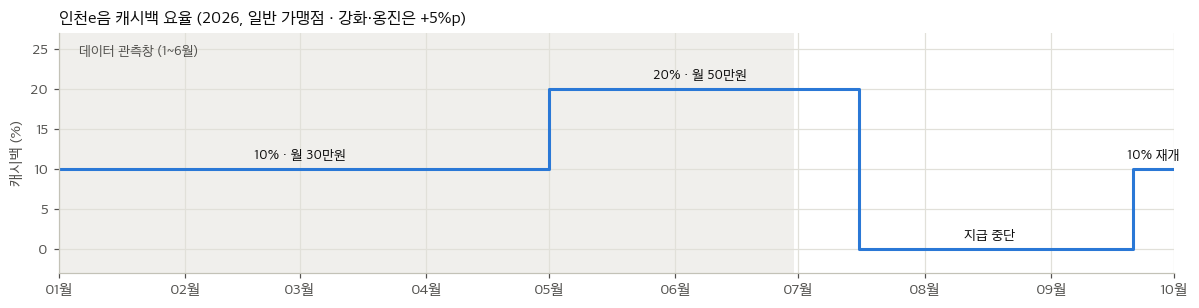

In [5]:
# 캐시백 요율 타임라인 (일반 가맹점) — 데이터 관측창과의 관계
D = dt.date
steps = [(D(2026, 1, 1), 10), (D(2026, 5, 1), 20), (D(2026, 7, 16), 0), (D(2026, 9, 21), 10), (D(2026, 10, 1), 10)]
fig, ax = plt.subplots(figsize=(11, 2.9))
ax.step([d for d, _ in steps], [r for _, r in steps], where="post", color=C["인천"])
ax.axvspan(D(2026, 1, 1), D(2026, 6, 30), color=C["wash"], zorder=0, lw=0)
ax.text(D(2026, 1, 6), 25.5, "데이터 관측창 (1~6월)", fontsize=9, color=C["ink2"], va="top")
for d, r, t in [(D(2026, 3, 1), 10, "10% · 월 30만원"), (D(2026, 6, 7), 20, "20% · 월 50만원"),
                (D(2026, 8, 17), 0, "지급 중단"), (D(2026, 9, 26), 10, "10% 재개")]:
    ax.annotate(t, (d, r), xytext=(0, 6), textcoords="offset points", ha="center", fontsize=9, color=C["ink"])
ax.set_xlim(D(2026, 1, 1), D(2026, 10, 1)); ax.set_ylim(-3, 27); ax.set_ylabel("캐시백 (%)")
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%m월"))
ax.set_title("인천e음 캐시백 요율 (2026, 일반 가맹점 · 강화·옹진은 +5%p)")
plt.tight_layout(); plt.show()

## 3. 인천 프로파일 — 규모와 구성이 전국과 얼마나 다른가
전국을 대조군으로 쓰려면 인천의 소비 구성이 전국과 크게 다르지 않아야 한다.

인천 결제금액 0.81조원 · 전국의 4.7% (17개 시도 중 7위)
인천 결제건수 0.47억 건 · 객단가 17,213원 (전국 18,149원)


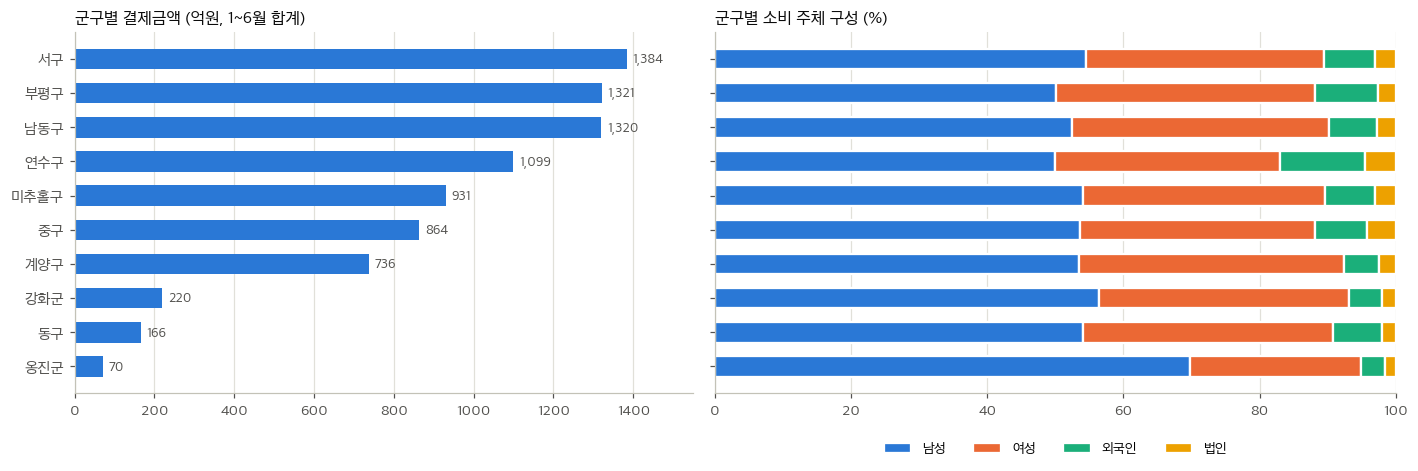

In [6]:
tot_amt, tot_cnt = df.amt.sum(), df.cnt.sum()
sido = df.groupby("SIDO_NM").agg(amt=("amt", "sum"), cnt=("cnt", "sum"))
rank_amt = int(sido.amt.rank(ascending=False)["인천광역시"])
print(f"인천 결제금액 {ic_all.amt.sum()/1e12:.2f}조원 · 전국의 {ic_all.amt.sum()/tot_amt*100:.1f}% (17개 시도 중 {rank_amt}위)")
print(f"인천 결제건수 {ic_all.cnt.sum()/1e8:.2f}억 건 · 객단가 {ic_all.amt.sum()/ic_all.cnt.sum():,.0f}원 (전국 {tot_amt/tot_cnt:,.0f}원)")

# 군구별 규모와 소비 주체 구성
g = ic_all.pivot_table(index="CCG_NM", columns="seg", values="amt", aggfunc="sum").fillna(0)[["남성", "여성", "외국인", "법인"]]
g = g.loc[g.sum(axis=1).sort_values().index]
tot = g.sum(axis=1) / EOK
share = g.div(g.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.1]})
ax = axes[0]
ax.barh(g.index, tot, color=C["인천"], height=0.6)
for i, v in enumerate(tot):
    ax.text(v + tot.max() * 0.01, i, f"{v:,.0f}", va="center", fontsize=9, color=C["ink2"])
ax.set_xlim(0, tot.max() * 1.12); ax.grid(axis="y", visible=False)
ax.set_title("군구별 결제금액 (억원, 1~6월 합계)")
ax = axes[1]
left = np.zeros(len(share))
for s, col in zip(share.columns, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]):
    ax.barh(share.index, share[s], left=left, color=col, height=0.6, label=s, edgecolor="white", linewidth=1.5)
    left += share[s].values
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False); ax.set_yticklabels([])
ax.set_title("군구별 소비 주체 구성 (%)"); ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1))
plt.tight_layout(); plt.show()

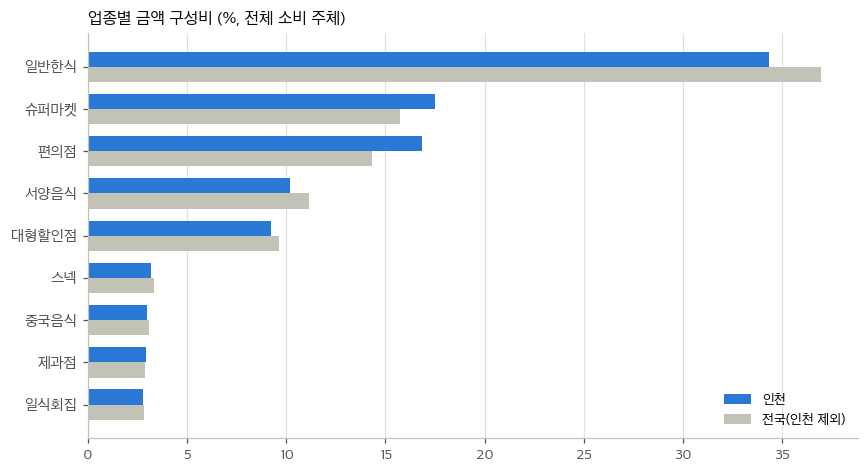

인천  전국(인천 제외)
소비 주체 구성 (%)      남성     52.8       51.0
                  여성     36.1       35.3
                  외국인     8.0        7.4
                  법인      3.1        6.3
연령 구성 (%, 내국인 개인) 20대 이하  1.0        1.0
                  20대     8.4        8.9
                  30대    15.2       15.2
                  40대    22.0       21.6
                  50대    25.8       26.0
                  60대 이상 27.6       27.4

In [7]:
def share_by(d, by):
    s = d.groupby(by).amt.sum(); return s / s.sum() * 100

comp = pd.DataFrame({"인천": share_by(ic_all, "biz"), "전국(인천 제외)": share_by(df[~df.is_ic], "biz")}).fillna(0)
comp = comp[comp.max(axis=1) >= 0.5].sort_values("전국(인천 제외)")          # 갈비전문점·한정식 제외

fig, ax = plt.subplots(figsize=(8, 4.4))
y = np.arange(len(comp)); h = 0.36
ax.barh(y + h / 2, comp["인천"], height=h, color=C["인천"], label="인천")
ax.barh(y - h / 2, comp["전국(인천 제외)"], height=h, color=C["ref"], label="전국(인천 제외)")
ax.set_yticks(y); ax.set_yticklabels(comp.index); ax.grid(axis="y", visible=False)
ax.set_title("업종별 금액 구성비 (%, 전체 소비 주체)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

seg_c = pd.DataFrame({"인천": share_by(ic_all, "seg"), "전국(인천 제외)": share_by(df[~df.is_ic], "seg")}).reindex(["남성", "여성", "외국인", "법인"])
age_c = pd.DataFrame({"인천": share_by(icn, "age"), "전국(인천 제외)": share_by(nat, "age")}).reindex(AGE_ORDER)
display(pd.concat({"소비 주체 구성 (%)": seg_c, "연령 구성 (%, 내국인 개인)": age_c}).round(1))

- 인천은 전국 결제금액의 4.7%(7위). **업종·연령 구성은 전국과 거의 같다**(일반한식 35% 안팎, 60대 이상 27% 등) → 전국·타 광역시를 대조군으로 쓰기에 구성 차이가 작다.
- 다른 점은 둘: **법인 비중이 낮고**(3.1% vs 6.3%), **동구는 대형할인점이 34%** 로 튄다. 법인은 어차피 e음을 쓸 수 없으므로 분석 기준은 내국인 개인으로 잡는다.

## 4. 시계열 — 인천 vs 전국: 언제부터 갈라지는가
규모가 다른 집단을 한 축에 놓기 위해 **1~4월 평균 = 100 지수**로 비교한다. 음영은 캐시백 20% 기간.

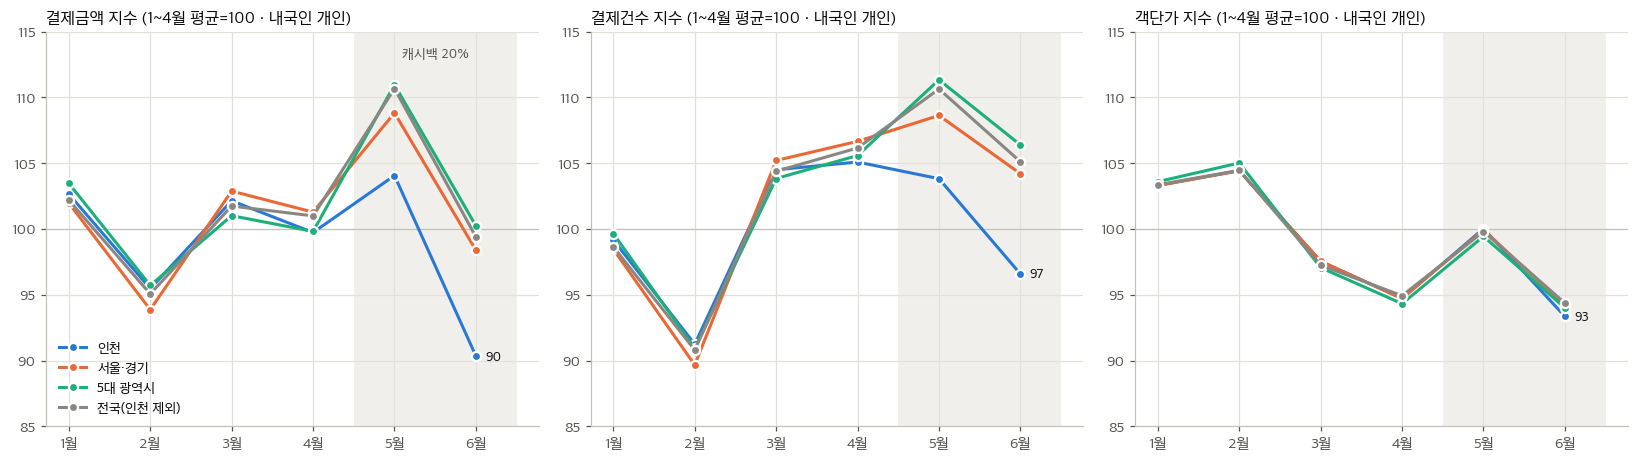

,금액 지수 5월,금액 지수 6월,금액 변화율 (5~6월 vs 1~4월),건수 변화율,객단가 변화율
인천,104.1,90.3,-2.8,0.2,-3.3
서울·경기,108.8,98.4,3.6,6.4,-2.9
5대 광역시,111.0,100.2,5.6,8.9,-3.3
전국(인천 제외),110.7,99.4,5.0,7.9,-2.9


In [8]:
GROUPS = {"인천": icn,
          "서울·경기": nat[nat.SIDO_NM.isin(["서울특별시", "경기도"])],
          "5대 광역시": nat[nat.SIDO_NM.isin(BIG5)],
          "전국(인천 제외)": nat}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (col, title) in zip(axes, [("amt", "결제금액"), ("cnt", "결제건수"), ("unit", "객단가")]):
    for name, d in GROUPS.items():
        s = munit(d) if col == "unit" else msum(d, col)
        line(ax, idx(s), name, label_end=(name == "인천"))
    shade(ax); ax.set_ylim(85, 115)
    ax.set_title(f"{title} 지수 (1~4월 평균=100 · 내국인 개인)")
axes[0].legend(loc="lower left"); axes[0].text(4.5, 113, "캐시백 20%", ha="center", fontsize=9, color=C["ink2"])
plt.tight_layout(); plt.show()

tab = {name: {"금액 지수 5월": idx(msum(d)).loc[202605], "금액 지수 6월": idx(msum(d)).loc[202606],
              "금액 변화율 (5~6월 vs 1~4월)": pp_total(d), "건수 변화율": pp_total(d, "cnt"),
              "객단가 변화율": (munit(d).loc[POST].mean() / munit(d).loc[PRE].mean() - 1) * 100}
       for name, d in GROUPS.items()}
display(pd.DataFrame(tab).T.round(1))

- 1~4월엔 네 집단이 ±1pt 안에서 같이 움직인다. **5월부터 인천만 처진다**(금액 104 vs 109~111) — 5월은 전국적으로 소비 피크인데 인천은 피크가 작고, **6월은 90 vs 98~100**으로 격차가 더 벌어진다.
- 건수도 같은 방향이고 **객단가는 차이가 없다** → 빠진 것은 "결제 건수"다. 결제 수단이 카드에서 e음으로 옮겨 갔다는 해석과 부합한다.

## 5. 사전 추세 검증과 반사실 갭 — "얼마나" 빠졌나
전국(인천 제외) 추세를 인천의 1~4월 수준에 적용한 값을 **반사실(counterfactual)** 로 두고, 실제와의 갭을 월별로 본다.
1~3월 갭이 0 근처면 평행 추세 가정이 성립한다.

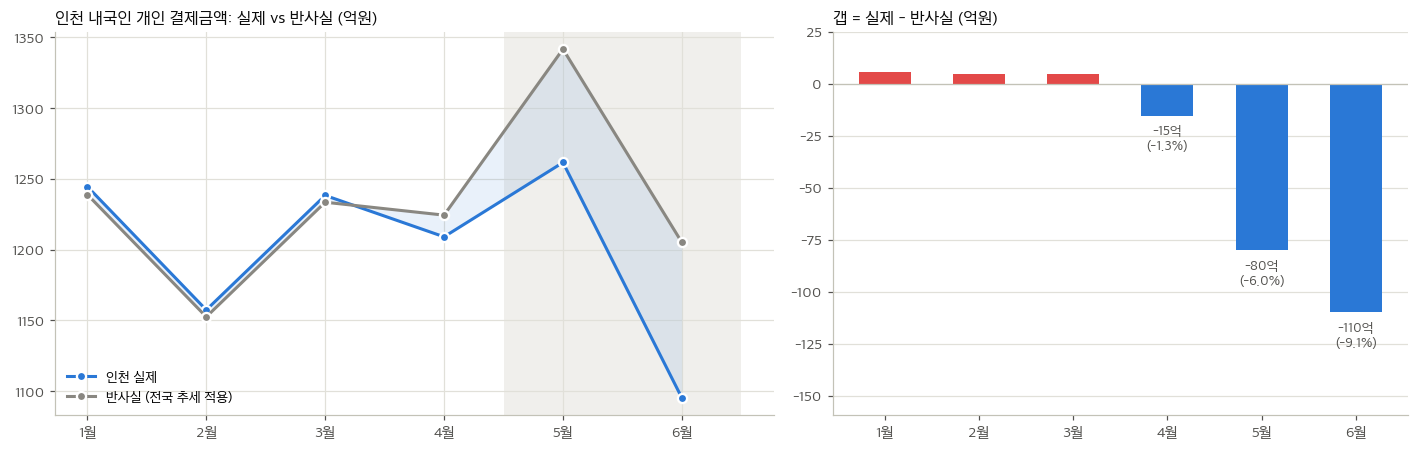

5~6월 갭 합계 -190억원  (5월 -6.0% · 6월 -9.1%)


STRD_YYMM,202601,202602,202603,202604,202605,202606
실제(억),"1,244.6","1,157.4","1,238.3","1,209.1","1,261.6","1,095.3"
반사실(억),"1,238.9","1,152.5","1,233.5","1,224.4","1,341.7","1,205.1"
갭(억),5.6,4.9,4.8,-15.3,-80.1,-109.9
갭(%),0.5,0.4,0.4,-1.3,-6.0,-9.1


In [9]:
ic_m, nat_m = msum(icn), msum(nat)
cf  = ic_m.loc[PRE].mean() * nat_m / nat_m.loc[PRE].mean()
gap = ic_m - cf; gap_pct = gap / cf * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
ax.plot(range(6), ic_m / EOK, marker="o", color=C["인천"], mec="white", mew=1.5, label="인천 실제", zorder=3)
ax.plot(range(6), cf / EOK, marker="o", color=C["전국(인천 제외)"], mec="white", mew=1.5, label="반사실 (전국 추세 적용)", zorder=3)
ax.fill_between(range(6), ic_m / EOK, cf / EOK, color=C["인천"], alpha=0.10, lw=0)
ax.axvspan(3.5, 5.5, color=C["wash"], zorder=0, lw=0); ax.set_xticks(range(6)); ax.set_xticklabels(MLAB)
ax.set_title("인천 내국인 개인 결제금액: 실제 vs 반사실 (억원)"); ax.legend(loc="lower left")
ax = axes[1]
ax.bar(range(6), gap / EOK, color=[C["인천"] if v < 0 else C["up"] for v in gap], width=0.55)
for i, (v, p) in enumerate(zip(gap / EOK, gap_pct)):
    if abs(p) >= 1:
        ax.text(i, v - 4, f"{v:,.0f}억\n({p:+.1f}%)", ha="center", va="top", fontsize=9, color=C["ink2"])
ax.axhline(0, color=C["ref"], lw=0.8); ax.set_xticks(range(6)); ax.set_xticklabels(MLAB)
ax.set_ylim(gap.min() / EOK * 1.45, 25); ax.grid(axis="x", visible=False)
ax.set_title("갭 = 실제 - 반사실 (억원)")
plt.tight_layout(); plt.show()

print(f"5~6월 갭 합계 {gap.loc[POST].sum()/EOK:,.0f}억원  (5월 {gap_pct.loc[202605]:+.1f}% · 6월 {gap_pct.loc[202606]:+.1f}%)")
display(pd.DataFrame({"실제(억)": ic_m / EOK, "반사실(억)": cf / EOK, "갭(억)": gap / EOK, "갭(%)": gap_pct}).round(1).T)

In [10]:
# 강건성 ① 대조군을 바꿔도 갭이 유지되는가
rows = {}
for name, d in {"전국(인천 제외)": nat, "서울·경기": GROUPS["서울·경기"], "5대 광역시": GROUPS["5대 광역시"]}.items():
    r = msum(d); c = ic_m.loc[PRE].mean() * r / r.loc[PRE].mean(); g_ = ic_m - c
    rows[name] = {"4월 갭%": (g_ / c * 100).loc[202604], "5월 갭%": (g_ / c * 100).loc[202605],
                  "6월 갭%": (g_ / c * 100).loc[202606], "5~6월 갭(억원)": g_.loc[POST].sum() / EOK}
display(pd.DataFrame(rows).T.round(1))

# 강건성 ② 균형패널 — 6개월 모두 수록된 셀만으로 다시 계산 (셀 출입에 의한 착시 배제)
b_ic, b_nat = msum(icn[icn.n_month == 6]), msum(nat[nat.n_month == 6])
b_cf = b_ic.loc[PRE].mean() * b_nat / b_nat.loc[PRE].mean()
print("균형패널 금액 커버리지:", f"{b_ic.sum()/ic_m.sum()*100:.1f}%", "· 갭%:", ((b_ic - b_cf) / b_cf * 100).round(1).to_dict())

,4월 갭%,5월 갭%,6월 갭%,5~6월 갭(억원)
전국(인천 제외),-1.3,-6.0,-9.1,-190.0
서울·경기,-1.5,-4.4,-8.2,-155.3
5대 광역시,-0.1,-6.2,-9.9,-203.6


균형패널 금액 커버리지: 100.0% · 갭%: {202601: 0.5, 202602: 0.4, 202603: 0.4, 202604: -1.3, 202605: -6.0, 202606: -9.1}


- **1~3월 갭 +0.4~0.5%** → 평행 추세 성립. **4월 -1.3%** 는 4/14 발표 이후 소비를 5월로 미룬 이연 효과일 수 있다(본분석에서 4월을 사전 기간에서 빼고 재확인).
- **5월 -6.0%, 6월 -9.1%, 두 달 합계 약 -190억원**(내국인 개인, BC카드 기준). 대조군을 서울·경기, 5대 광역시로 바꿔도 -4~-10%로 유지되고, 균형패널에서도 같다.
- 6월이 5월보다 큰 것은 e음 가입·충전이 5월에 폭증한 뒤 6월에 사용이 본격화된 흐름과 맞는다. 7월(중단)이 데이터에 없는 것이 아쉽다.

## 6. 전국 속 인천의 위치 — 우연히 낮은 것인가
5~6월 vs 1~4월 변화율을 시도·시군구 단위로 늘어놓고 인천이 어디에 있는지 본다.

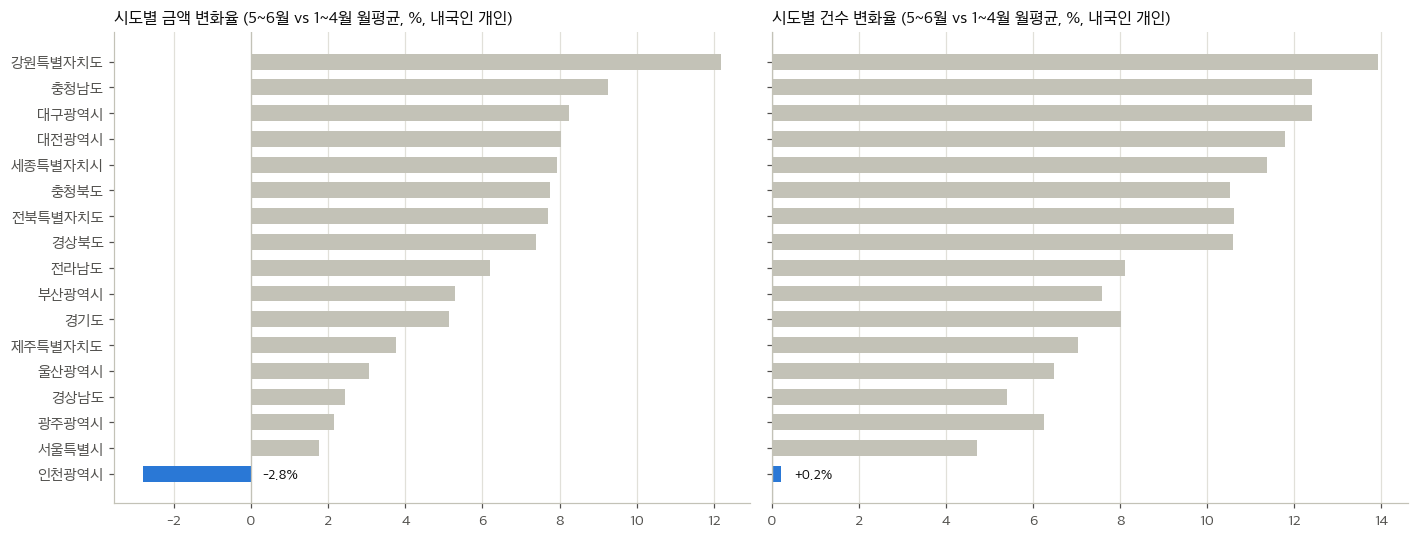

In [11]:
sd = pd.DataFrame({"금액": prepost(ind, "SIDO_NM"), "건수": prepost(ind, "SIDO_NM", "cnt")}).sort_values("금액")
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, col in zip(axes, ["금액", "건수"]):
    ax.barh(sd.index, sd[col], color=[C["인천"] if s == "인천광역시" else C["ref"] for s in sd.index], height=0.62)
    v = sd.loc["인천광역시", col]; i = list(sd.index).index("인천광역시")
    ax.text(0.3 if v < 0 else v + 0.3, i, f"{v:+.1f}%", ha="left", va="center", fontsize=9, color=C["ink"])
    ax.axvline(0, color=C["ref"], lw=0.8); ax.grid(axis="y", visible=False)
    ax.set_title(f"시도별 {col} 변화율 (5~6월 vs 1~4월 월평균, %, 내국인 개인)")
plt.tight_layout(); plt.show()

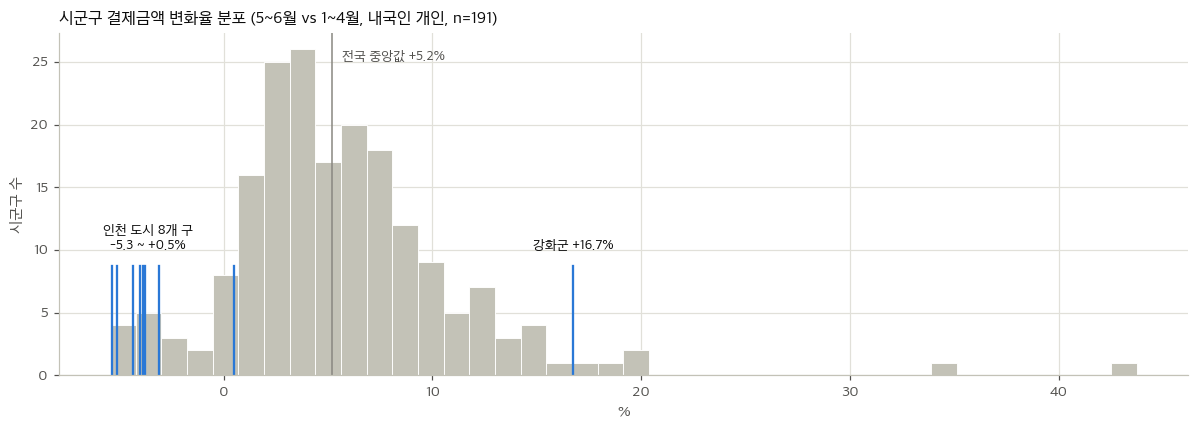

,변화율 %,"전국 순위 (낮은 순, n=191)"
region,,
인천광역시 계양구,-5.3,2
인천광역시 남동구,-5.1,3
인천광역시 연수구,-4.3,4
인천광역시 서구,-4.0,6
인천광역시 동구,-3.9,7
인천광역시 미추홀구,-3.7,8
인천광역시 부평구,-3.1,9
인천광역시 중구,0.5,20
인천광역시 강화군,16.7,186


In [12]:
pre_reg = ind[ind.STRD_YYMM.isin(PRE)].groupby("region").amt.sum() / len(PRE)
reg_pp  = prepost(ind, "region")
reg_pp  = reg_pp[pre_reg >= pre_reg.quantile(0.25)]             # 규모 하위 25% 제외 (옹진군 포함) — 소규모 노이즈 차단
ic_pp   = reg_pp[reg_pp.index.str.startswith("인천")].sort_values()
urban   = ic_pp[~ic_pp.index.str.contains("강화군|옹진군")]

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(reg_pp, bins=40, color=C["ref"], edgecolor="white", linewidth=0.6)
ymax = ax.get_ylim()[1]
ax.axvline(reg_pp.median(), color=C["muted"], lw=1)
ax.text(reg_pp.median() + 0.5, ymax * 0.95, f"전국 중앙값 {reg_pp.median():+.1f}%", fontsize=9, color=C["ink2"], va="top")
for r, v in ic_pp.items():
    ax.axvline(v, color=C["인천"], lw=1.5, ymax=0.32)
ax.annotate(f"인천 도시 8개 구\n{urban.min():+.1f} ~ {urban.max():+.1f}%", (urban.mean(), ymax * 0.36), ha="center", va="bottom", fontsize=9, color=C["ink"])
for r in [x for x in ["인천광역시 강화군", "인천광역시 옹진군"] if x in ic_pp.index]:
    ax.annotate(f"{r.split()[-1]} {ic_pp[r]:+.1f}%", (ic_pp[r], ymax * 0.36), ha="center", va="bottom", fontsize=9, color=C["ink"])
ax.set_xlabel("%"); ax.set_ylabel("시군구 수")
ax.set_title(f"시군구 결제금액 변화율 분포 (5~6월 vs 1~4월, 내국인 개인, n={len(reg_pp)})")
plt.tight_layout(); plt.show()

rk = reg_pp.rank().astype(int)
display(pd.DataFrame({"변화율 %": ic_pp, f"전국 순위 (낮은 순, n={len(reg_pp)})": rk[ic_pp.index]}).round(1))

- 인천은 17개 시도 중 **유일한 마이너스**(금액 -2.8%)이고, 건수도 유일하게 0 근처다. 두 번째로 낮은 서울과도 4~5pt 차이.
- 시군구로 내려가면 **도시 8개 구 중 7개가 전국 191곳 중 하위 9위 안**에 몰려 있다. 개별 상권의 문제가 아니라 **도시 단위 충격**이다.

## 7. 업종별 — e음을 쓸 수 있는 업종에서만 빠지는가 (플라시보 검정)
대형할인점(대형마트·SSM)은 e음 결제가 안 된다. 대체효과라면 **대형할인점의 인천-전국 격차는 0 근처**여야 하고, 소상공인 업종에서만 격차가 나야 한다.

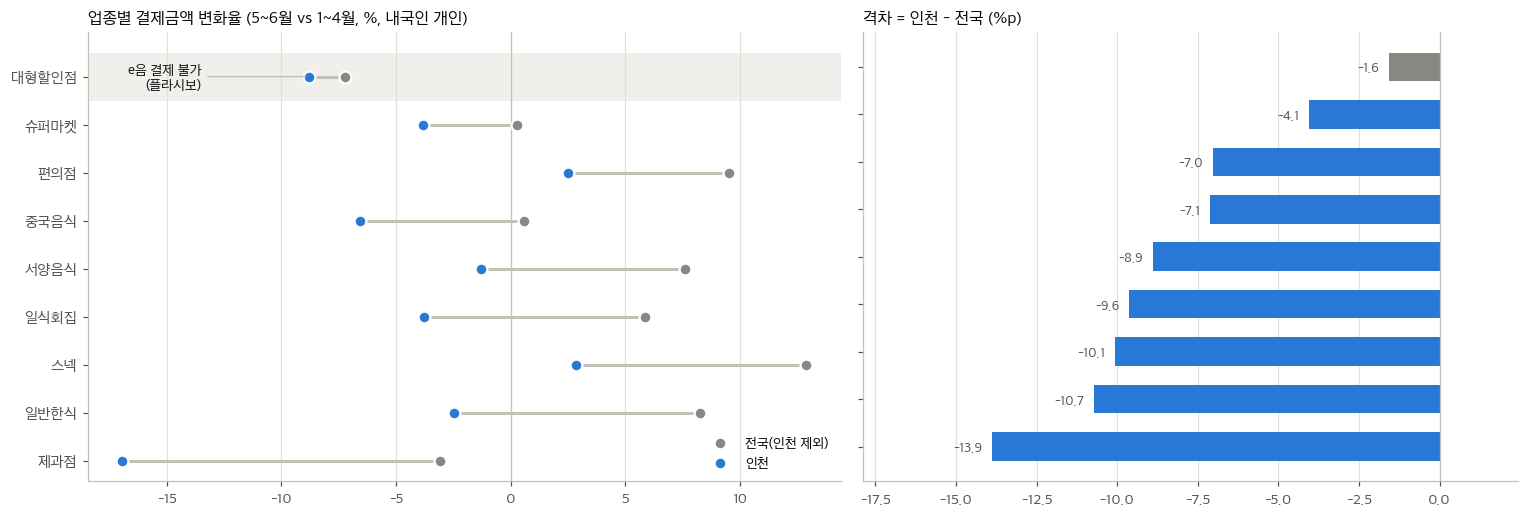

,인천 금액(억),인천,전국(인천 제외),격차(금액),인천 건수,전국 건수,격차(건수)
biz,,,,,,,
제과점,200.3,-16.9,-3.1,-13.9,-11.6,0.3,-11.8
일반한식,"2,557.7",-2.5,8.2,-10.7,-2.9,7.7,-10.6
스넥,234.7,2.8,12.9,-10.1,-1.3,8.4,-9.7
일식회집,208.2,-3.8,5.9,-9.6,-1.9,8.4,-10.4
서양음식,705.1,-1.3,7.6,-8.9,3.8,11.9,-8.1
중국음식,210.7,-6.6,0.6,-7.1,-6.0,1.3,-7.3
편의점,"1,183.0",2.5,9.5,-7.0,4.1,11.1,-7.0
슈퍼마켓,"1,236.1",-3.8,0.3,-4.1,-2.7,3.7,-6.4
대형할인점,669.8,-8.8,-7.2,-1.6,-6.3,-4.5,-1.8


In [13]:
biz_amt = icn.groupby("biz").amt.sum() / EOK
bz = pd.DataFrame({"인천 금액(억)": biz_amt,
                   "인천": prepost(icn, "biz"), "전국(인천 제외)": prepost(nat, "biz"),
                   "인천 건수": prepost(icn, "biz", "cnt"), "전국 건수": prepost(nat, "biz", "cnt")})
bz["격차(금액)"] = bz["인천"] - bz["전국(인천 제외)"]; bz["격차(건수)"] = bz["인천 건수"] - bz["전국 건수"]
bz = bz[bz["인천 금액(억)"] >= 10].sort_values("격차(금액)")       # 갈비전문점·한정식(인천 1억 미만) 제외
PLACEBO = "대형할인점"

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
y = np.arange(len(bz)); i_p = list(bz.index).index(PLACEBO)
ax = axes[0]
ax.axhspan(i_p - 0.5, i_p + 0.5, color=C["wash"], zorder=0, lw=0)
ax.hlines(y, bz["전국(인천 제외)"], bz["인천"], color=C["ref"], lw=2, zorder=2)
ax.scatter(bz["전국(인천 제외)"], y, s=60, color=C["전국(인천 제외)"], ec="white", lw=1.5, zorder=3, label="전국(인천 제외)")
ax.scatter(bz["인천"], y, s=60, color=C["인천"], ec="white", lw=1.5, zorder=3, label="인천")
ax.annotate("e음 결제 불가\n(플라시보)", (bz.loc[PLACEBO, "인천"], i_p), xytext=(-70, 0), textcoords="offset points",
            va="center", ha="right", fontsize=9, color=C["ink"], arrowprops=dict(arrowstyle="-", color=C["ref"]))
ax.set_yticks(y); ax.set_yticklabels(bz.index); ax.axvline(0, color=C["ref"], lw=0.8); ax.grid(axis="y", visible=False)
ax.set_title("업종별 결제금액 변화율 (5~6월 vs 1~4월, %, 내국인 개인)"); ax.legend(loc="lower right")
ax = axes[1]
ax.barh(y, bz["격차(금액)"], color=[C["muted"] if b == PLACEBO else C["인천"] for b in bz.index], height=0.6)
for i, v in enumerate(bz["격차(금액)"]):
    ax.text(v - 0.3 if v < 0 else v + 0.3, i, f"{v:+.1f}", va="center", ha="right" if v < 0 else "left", fontsize=9, color=C["ink2"])
ax.set_yticks(y); ax.set_yticklabels([]); ax.axvline(0, color=C["ref"], lw=0.8); ax.grid(axis="y", visible=False)
ax.set_xlim(bz["격차(금액)"].min() - 4, bz["격차(금액)"].max() + 4)
ax.set_title("격차 = 인천 - 전국 (%p)")
plt.tight_layout(); plt.show()

display(bz[["인천 금액(억)", "인천", "전국(인천 제외)", "격차(금액)", "인천 건수", "전국 건수", "격차(건수)"]].round(1))

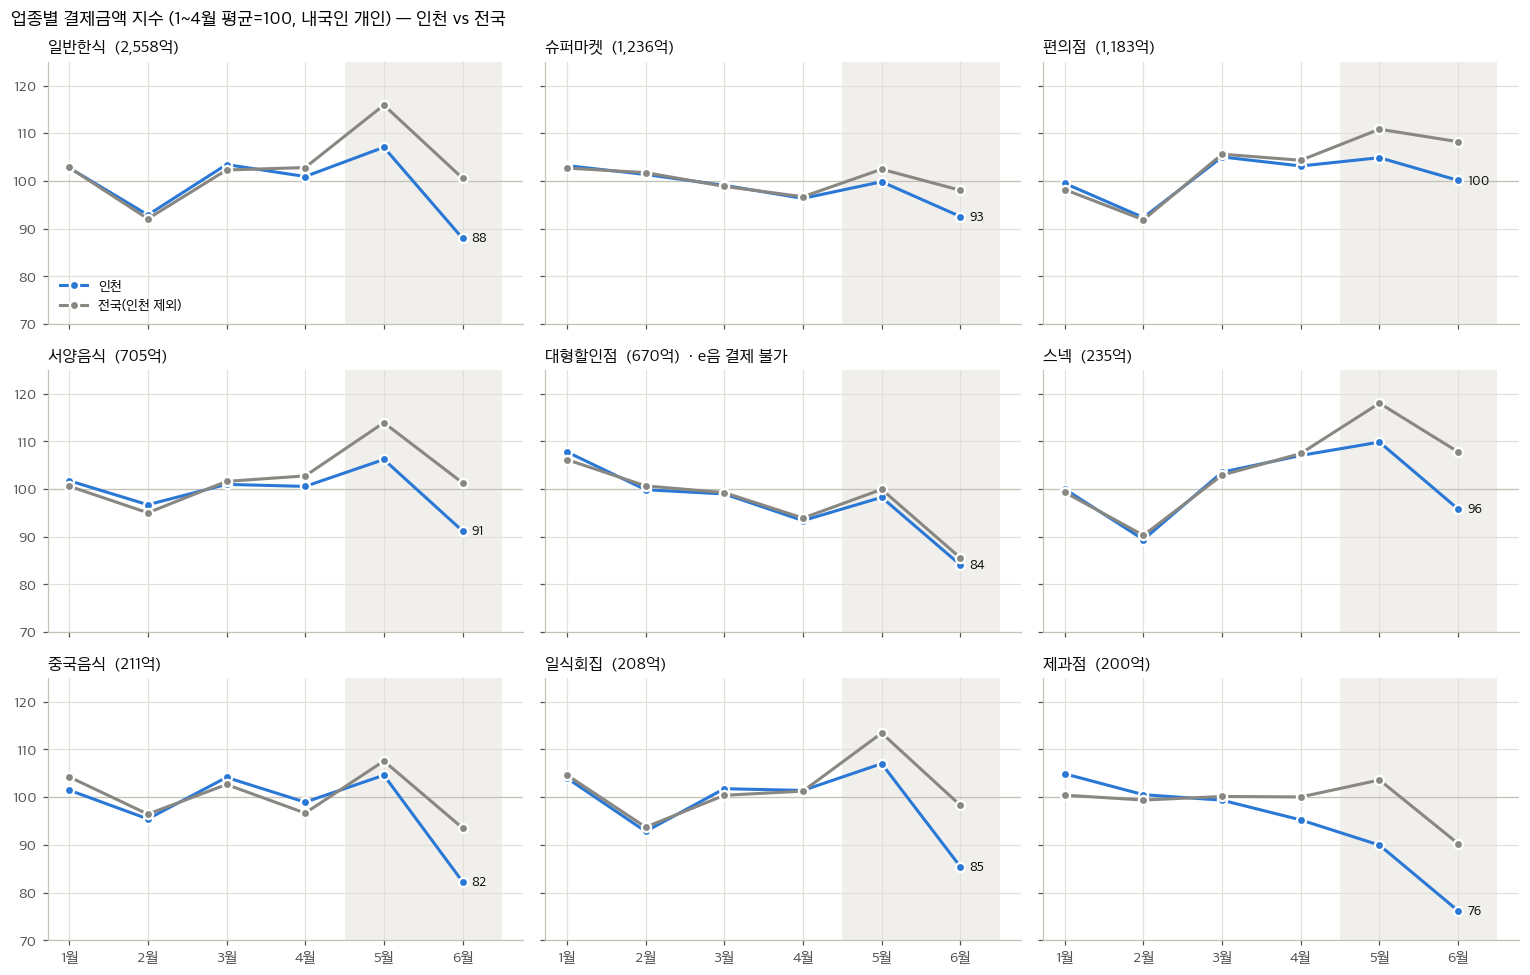

In [14]:
top9 = biz_amt.sort_values(ascending=False).index[:9]
fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True, sharey=True)
for ax, b in zip(axes.flat, top9):
    line(ax, idx(msum(icn[icn.biz == b])), "인천")
    line(ax, idx(msum(nat[nat.biz == b])), "전국(인천 제외)", label_end=False)
    shade(ax); ax.set_title(f"{b}  ({biz_amt[b]:,.0f}억)" + ("  · e음 결제 불가" if b == PLACEBO else ""))
axes[0, 0].set_ylim(70, 125); axes[0, 0].legend(loc="lower left")
fig.suptitle("업종별 결제금액 지수 (1~4월 평균=100, 내국인 개인) — 인천 vs 전국", x=0.01, ha="left", fontsize=12, fontweight="semibold")
plt.tight_layout(); plt.show()

- **대형할인점(e음 불가) 격차 -1.6pt ≈ 0.** 인천도 전국도 5~6월에 똑같이 빠졌다(계절 요인). 반면 **소상공인 업종은 -7~-14pt** — 제과점·일반한식·스넥·일식회집·서양음식 순으로 크다.
- 격차의 크기가 **e음 적격성과 맞아떨어지는 것**이 이 EDA에서 가장 강한 대체효과 증거다. 슈퍼마켓 격차(-4pt)가 작은 것은 SSM(e음 불가)이 섞여 있기 때문으로 보인다.
- 지수 그림에서 인천 소상공인 업종은 5월 피크가 작고 6월 낙폭이 크다. 대형할인점은 두 선이 겹친다.

## 8. 군구별 — 도시 8개 구 vs 강화·옹진
강화·옹진은 캐시백이 25%로 더 높지만, 소비의 주체가 관광객(비인천 거주자)이라 e음 대체가 일어나기 어렵다. 따로 봐야 한다.

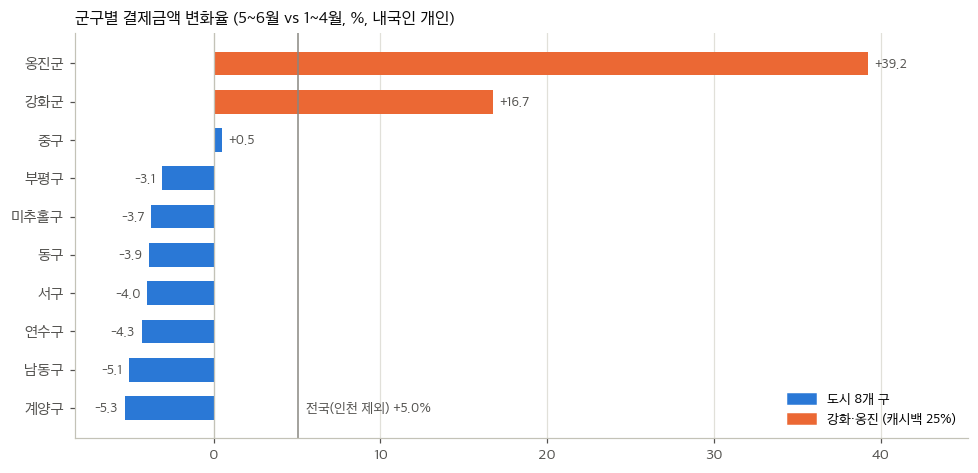

CCG_NM,계양구,남동구,연수구,서구,동구,미추홀구,부평구,중구,강화군,옹진군
변화율,-5.3,-5.1,-4.3,-4.0,-3.9,-3.7,-3.1,0.5,16.7,39.2
금액(억),680.8,"1,191.4",912.2,"1,239.2",150.3,834.8,"1,165.3",761.5,204.4,66.3


In [15]:
ccg = pd.DataFrame({"변화율": prepost(icn, "CCG_NM"), "금액(억)": icn.groupby("CCG_NM").amt.sum() / EOK}).sort_values("변화율")
ref_nat = pp_total(nat); ISLAND = ("강화군", "옹진군")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(ccg.index, ccg["변화율"], color=[C["서울·경기"] if c in ISLAND else C["인천"] for c in ccg.index], height=0.62)
for i, v in enumerate(ccg["변화율"]):
    ax.text(v + 0.4 if v >= 0 else v - 0.4, i, f"{v:+.1f}", va="center", ha="left" if v >= 0 else "right", fontsize=9, color=C["ink2"])
ax.axvline(0, color=C["ref"], lw=0.8); ax.axvline(ref_nat, color=C["muted"], lw=1)
ax.text(ref_nat + 0.5, 0, f"전국(인천 제외) {ref_nat:+.1f}%", fontsize=9, color=C["ink2"], va="center")
ax.set_xlim(ccg["변화율"].min() - 3, ccg["변화율"].max() + 6); ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=C["인천"], label="도시 8개 구"), Patch(color=C["서울·경기"], label="강화·옹진 (캐시백 25%)")], loc="lower right")
ax.set_title("군구별 결제금액 변화율 (5~6월 vs 1~4월, %, 내국인 개인)")
plt.tight_layout(); plt.show()
display(ccg.round(1).T)

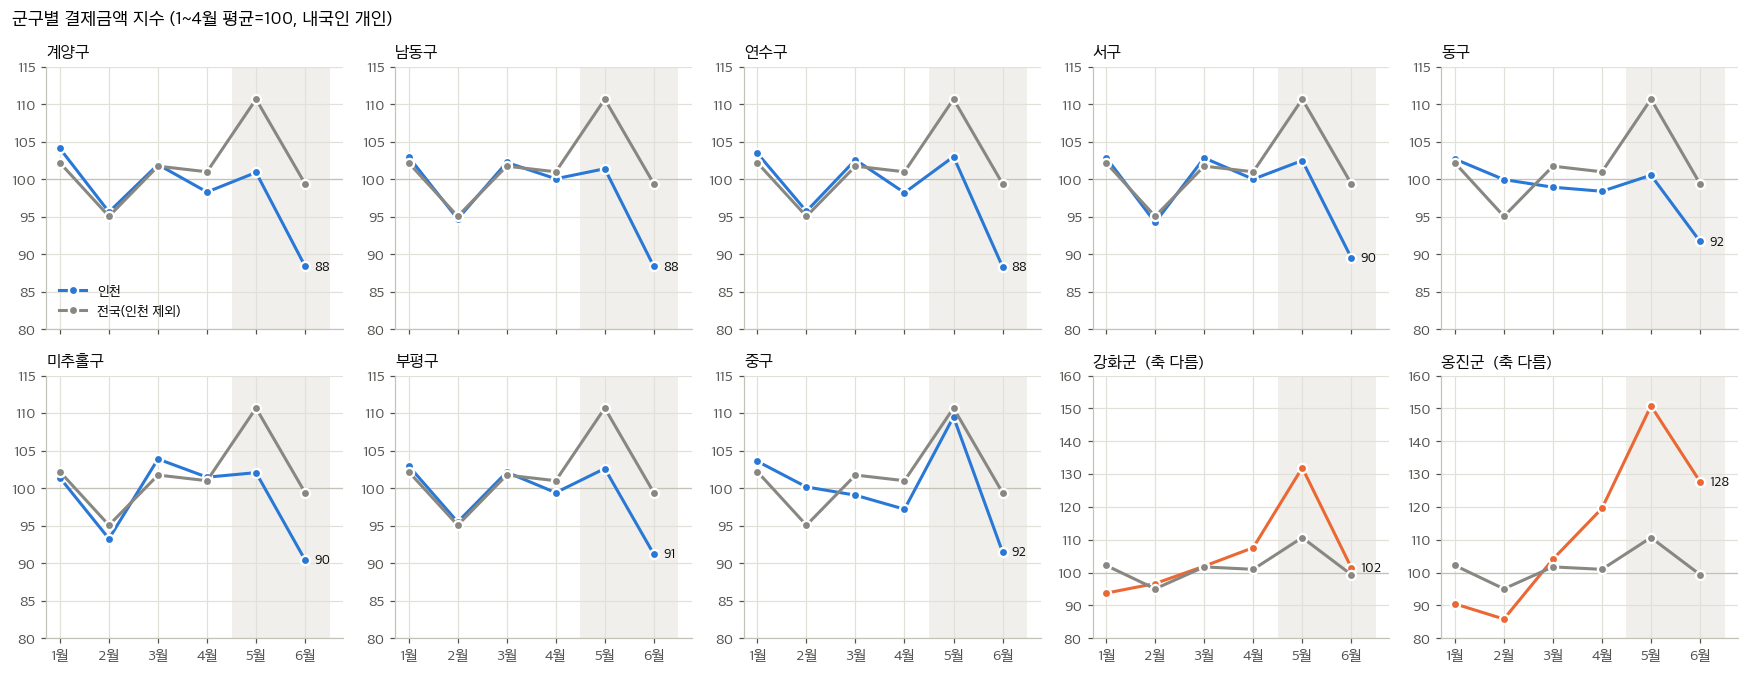

In [16]:
order = ["계양구", "남동구", "연수구", "서구", "동구", "미추홀구", "부평구", "중구", "강화군", "옹진군"]
nat_idx = idx(msum(nat))
fig, axes = plt.subplots(2, 5, figsize=(16, 6.2), sharex=True)
for ax, c in zip(axes.flat, order):
    line(ax, idx(msum(icn[icn.CCG_NM == c])), "인천", color=C["서울·경기"] if c in ISLAND else C["인천"])
    line(ax, nat_idx, "전국(인천 제외)", label_end=False)
    shade(ax); ax.set_ylim((80, 160) if c in ISLAND else (80, 115))
    ax.set_title(c + ("  (축 다름)" if c in ISLAND else ""))
axes[0, 0].legend(loc="lower left")
fig.suptitle("군구별 결제금액 지수 (1~4월 평균=100, 내국인 개인)", x=0.01, ha="left", fontsize=12, fontweight="semibold")
plt.tight_layout(); plt.show()

In [17]:
# 강화·옹진의 상승은 정책 효과가 아니라 전국 군(郡) 단위의 봄 관광 계절성과 같은 패턴인가
typ = pd.Series(np.where(reg_pp.index.str.endswith("군"), "군", "시·구"), index=reg_pp.index)
print("유형별 변화율 중앙값(%):", reg_pp.groupby(typ).median().round(1).to_dict())
gun = reg_pp[typ == "군"].sort_values(ascending=False)
display(pd.DataFrame({"변화율 %": gun.head(10), "군 중 순위": gun.rank(ascending=False).astype(int).head(10)}).round(1).T)
print(f"강화군: {gun['인천광역시 강화군']:+.1f}% (군 {len(gun)}곳 중 {int(gun.rank(ascending=False)['인천광역시 강화군'])}위) · 옹진군은 규모 필터로 분포에서 제외 (원자료 {ccg.loc['옹진군', '변화율']:+.1f}%)")

유형별 변화율 중앙값(%): {'군': 12.1, '시·구': 4.2}


region,충청남도 태안군,경기도 가평군,경상남도 남해군,경기도 양평군,인천광역시 강화군,경상남도 함안군,전라남도 담양군,전라남도 해남군,강원특별자치도 홍천군,전라남도 무안군
변화율 %,43.7,34.9,20.2,19.3,16.7,14.9,14.7,12.6,12.4,12.3
군 중 순위,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0


강화군: +16.7% (군 21곳 중 5위) · 옹진군은 규모 필터로 분포에서 제외 (원자료 +39.2%)


- **도시 8개 구 중 7곳이 -3.1 ~ -5.3%로 고르게** 빠졌다(중구만 +0.5%). 특정 상권이 아니라 시 전체가 같은 방향 → 시 단위 정책 충격과 부합.
- **강화·옹진은 +17%, +39%.** 캐시백이 가장 높은 곳인데도 오른 것은, 이곳 카드소비가 방문객 중심이고 전국 군 단위가 봄에 +12%(중앙값) 오르는 관광 계절성을 그대로 따르기 때문이다. 본분석에서는 처치군에서 분리한다.

## 9. 소비 주체·연령·성별 — 누가 갈아탔나
법인카드는 e음을 쓸 수 없고, 외국인은 외국인등록증으로 가입할 수 있다. 개인은 성별·연령을 가리지 않고 빠졌는지 본다.

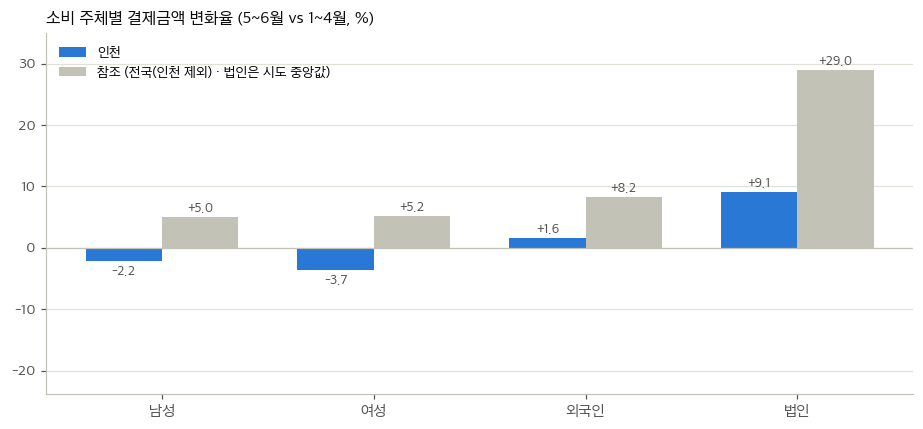

,남성,여성,외국인,법인
인천,-2.2,-3.7,1.6,9.1
참조,5.0,5.2,8.2,29.0
격차,-7.1,-8.9,-6.6,-19.9


법인 시도별 변화율(%) — 분산이 매우 커서 법인은 약한 대조군:
SIDO_NM
세종특별자치시     6.6
대구광역시       8.9
인천광역시       9.1
충청북도       11.6
경상북도       13.7
대전광역시      17.1
서울특별시      19.1
경기도        22.3
충청남도       26.4
강원특별자치도    31.6
전북특별자치도    34.3
광주광역시      68.7
제주특별자치도   109.9
전라남도      206.7
울산광역시     208.7
부산광역시     301.4
경상남도      592.6


In [18]:
corp, frn = df[df.seg == "법인"], df[df.seg == "외국인"]
corp_sido = prepost(corp, "SIDO_NM").sort_values()
ref_corp  = corp_sido.drop("인천광역시").median()        # 법인은 부산·경남 등 이상 급증 → 전국 합계 대신 시도 중앙값을 참조로

segs = pd.DataFrame({
    "인천": [pp_total(icn[icn.seg == "남성"]), pp_total(icn[icn.seg == "여성"]), pp_total(frn[frn.is_ic]), pp_total(corp[corp.is_ic])],
    "참조": [pp_total(nat[nat.seg == "남성"]), pp_total(nat[nat.seg == "여성"]), pp_total(frn[~frn.is_ic]), ref_corp],
}, index=["남성", "여성", "외국인", "법인"])
segs["격차"] = segs["인천"] - segs["참조"]

fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(4); w = 0.36
ax.bar(x - w / 2, segs["인천"], width=w, color=C["인천"], label="인천")
ax.bar(x + w / 2, segs["참조"], width=w, color=C["ref"], label="참조 (전국(인천 제외) · 법인은 시도 중앙값)")
for i in range(4):
    for dx, col in [(-w / 2, "인천"), (w / 2, "참조")]:
        v = segs.iloc[i][col]
        ax.text(i + dx, v + 0.5 if v >= 0 else v - 0.5, f"{v:+.1f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9, color=C["ink2"])
ax.set_xticks(x); ax.set_xticklabels(segs.index); ax.axhline(0, color=C["ref"], lw=0.8); ax.grid(axis="x", visible=False)
ax.set_ylim(segs.min().min() - 4, segs.max().max() + 6)
ax.set_title("소비 주체별 결제금액 변화율 (5~6월 vs 1~4월, %)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
display(segs.round(1).T)
print("법인 시도별 변화율(%) — 분산이 매우 커서 법인은 약한 대조군:"); print(corp_sido.round(1).to_string())

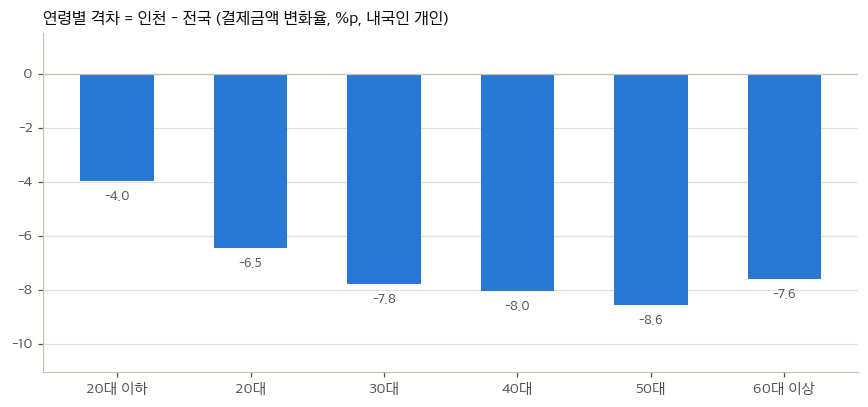

인천  전국(인천 제외)   격차
연령 20대 이하 -3.0        1.0 -4.0
   20대    -3.9        2.5 -6.5
   30대    -4.1        3.7 -7.8
   40대    -4.6        3.4 -8.0
   50대    -4.3        4.2 -8.6
   60대 이상  1.2        8.8 -7.6
성별 남성     -2.2        5.0 -7.1
   여성     -3.7        5.2 -8.9

In [19]:
age_pp = pd.DataFrame({"인천": prepost(icn, "age"), "전국(인천 제외)": prepost(nat, "age")}).reindex(AGE_ORDER)
age_pp["격차"] = age_pp["인천"] - age_pp["전국(인천 제외)"]
gen_pp = pd.DataFrame({"인천": prepost(icn, "seg"), "전국(인천 제외)": prepost(nat, "seg")})
gen_pp["격차"] = gen_pp["인천"] - gen_pp["전국(인천 제외)"]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(range(6), age_pp["격차"], color=C["인천"], width=0.55)
for i, v in enumerate(age_pp["격차"]):
    ax.text(i, v - 0.3, f"{v:+.1f}", ha="center", va="top", fontsize=9, color=C["ink2"])
ax.set_xticks(range(6)); ax.set_xticklabels(AGE_ORDER); ax.axhline(0, color=C["ref"], lw=0.8); ax.grid(axis="x", visible=False)
ax.set_ylim(age_pp["격차"].min() - 2.5, 1.5)
ax.set_title("연령별 격차 = 인천 - 전국 (결제금액 변화율, %p, 내국인 개인)")
plt.tight_layout(); plt.show()
display(pd.concat({"연령": age_pp, "성별": gen_pp}).round(1))

- 개인은 **성별·연령을 가리지 않고 -4 ~ -9pt** 빠졌고, 30~50대가 가장 크다. 외국인도 -6.6pt로 개인과 같은 방향.
- **법인은 마이너스가 아니다**(+9.1%). 시도 중앙값(+29%)보다는 낮지만 법인은 5~6월 전국적으로 이상 급증(부산·경남 수백 %)이 있어 분산이 커, 방향만 확인하는 정도로 쓴다.

## 10. 인접 지역 — 경계 밖으로 새는가
인천 거주자가 e음을 쓰려고 소비를 인천 안으로 되돌렸다면, 인접한 경기 지역(부천·김포·시흥)의 소비가 함께 약해질 수 있다.

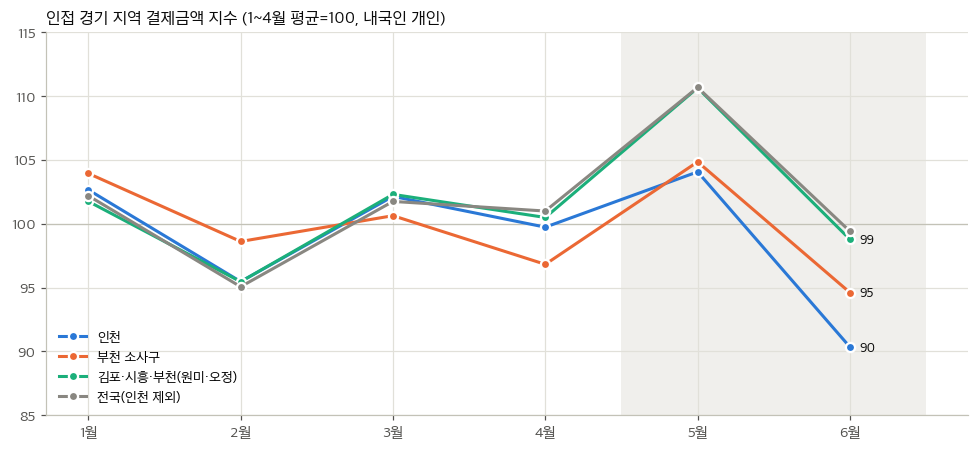

CCG_NM,김포시,부천시 소사구,부천시 오정구,부천시 원미구,시흥시
변화율 % (5~6월 vs 1~4월),4.1,-0.3,5.5,4.0,5.4
전국(인천 제외),5.0,5.0,5.0,5.0,5.0


In [20]:
NB = {"부천 소사구": ["부천시 소사구"], "김포·시흥·부천(원미·오정)": ["김포시", "시흥시", "부천시 원미구", "부천시 오정구"]}
fig, ax = plt.subplots(figsize=(9, 4.2))
line(ax, idx(msum(icn)), "인천")
for name, ccgs in NB.items():
    d = nat[nat.SIDO_NM.eq("경기도") & nat.CCG_NM.isin(ccgs)]
    line(ax, idx(msum(d)), name, color=C["서울·경기"] if "소사" in name else C["5대 광역시"])
line(ax, idx(msum(nat)), "전국(인천 제외)", label_end=False)
shade(ax); ax.set_ylim(85, 115); ax.legend(loc="lower left")
ax.set_title("인접 경기 지역 결제금액 지수 (1~4월 평균=100, 내국인 개인)")
plt.tight_layout(); plt.show()

nb_all = nat[nat.SIDO_NM.eq("경기도") & nat.CCG_NM.isin(sum(NB.values(), []))]
display(pd.DataFrame({"변화율 % (5~6월 vs 1~4월)": prepost(nb_all, "CCG_NM"),
                      "전국(인천 제외)": pp_total(nat)}).round(1).T)

- 인접 지역 대부분은 전국과 같이 움직인다. **부천 소사구만** 인천과 비슷하게 처진다(경계 상권 유출 가능성). 본분석에서 인접 시군구를 대조군에 넣을지, 별도 스필오버 군으로 뺄지 결정할 근거.

## 11. 요약과 본분석 설계

### 핵심 발견
| # | 발견 | 근거 |
|---|---|---|
| 1 | 인천 BC카드 개인 소비는 1~4월엔 전국과 동행하다가 **5월 -6.0%, 6월 -9.1%** 갭 (두 달 약 **-190억원**) | 5장 |
| 2 | 17개 시도 중 **유일한 마이너스**, 도시 8개 구 중 7개가 전국 하위 9위 안 | 6장 |
| 3 | **e음 불가 업종(대형할인점) 격차 ≈ 0, 소상공인 업종 -7~-14pt** — 정책 적격성과 격차가 일치 | 7장 |
| 4 | 개인은 전 연령·성별·외국인까지 빠졌고, **법인은 빠지지 않음** | 9장 |
| 5 | 강화·옹진의 상승은 군 단위 관광 계절성, 인접 지역 중 부천 소사구만 동반 약세 | 8·10장 |

### 본분석 설계 (EDA가 정한 것)
- **처치군** 인천 도시 8개 구 × 내국인 개인 (강화·옹진은 별도 처리) · **대조군** 5대 광역시 또는 전국 시군구 (부천 소사구 등 인접 지역 제외 여부 검토)
- **사전/사후** 1~4월 / 5~6월 (4월 이연 가능성 → 1~3월만으로도 재추정) · **결과 변수** 금액·건수 (객단가는 변화 없음)
- **이중차분(DID)** 인천 × 사후 · **삼중차분(DDD)** 에 업종 적격 여부(대형할인점 = 플라시보)를 더해 계절·지역 공통 충격 제거
- **이벤트 스터디** 월별 계수로 4월 선행, 5→6월 확대 확인 · **대체율** = BC카드 갭 ÷ e음 결제 증가액 (외부 데이터 필요)

### 한계
- BC카드 한 회사의 데이터 → 대체 규모는 BC 점유율만큼만 보인다. 6개월뿐이라 연간 계절성을 완전히 통제할 수 없고, **7월 캐시백 중단 국면이 없다.**
- e음 결제액·가입자, 인구, 카드사 점유율이 없어 1인당 정규화와 대체율 산출은 외부 데이터가 있어야 한다.
- 5~6월 법인 소비의 전국적 이상 급증(부산·경남)은 법인을 대조군으로 쓰기 어렵게 한다.

### 필요한 외부 데이터
인천e음 월별 결제액·충전액·가입자(인천시/코나아이) · 시군구 주민등록인구 · 카드사별 시장점유율 · 소상공인 가맹점 수